In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import roots_legendre
from numba import njit
from mpmath import polylog
from scipy.optimize import minimize, root_scalar
from functools import lru_cache

In [ ]:
# Parámetros iniciales
m = 88.7233211870863
g = 2.76300879989615
lamda = 0.9
mu = 1
T_v = np.linspace(120, 200, 1000)  
n2_puntos = 200  
n3_puntos = 200 
nodos2, pesos2 = roots_legendre(n2_puntos)
nodos3, pesos3 = roots_legendre(n3_puntos)

In [18]:
#Segunda derivada version mixta
#------------------------------------------------------------------------
#Integral del term_3

def D2_Int_3(T, mu_q, nodos2, pesos2):

    k_v = (1 + nodos2) / (1 - nodos2)
    dk = 2 / (1 - nodos2)**2
    Int_vals = np.zeros_like(k_v, dtype=np.complex128)

    def PI(T, mu_q):
        exp_1 = -np.exp(mu_q/T)
        exp_2 = -np.exp(-mu_q/T)

        term_1 = (lamda*T**2)/2
        term_2 = -((g**2*T**2)/np.pi**2)*(polylog(2, exp_1) + polylog(2, exp_2))

        Autoenergia= float(term_1 + term_2)
        return Autoenergia
    Pi = PI(T, mu_q)

    for i in range(len(k_v)):
        k = k_v[i]

        arg = k**2 + Pi
        raiz = np.sqrt(arg + 0j)
        exp_arg_1 = np.exp(-(-mu_q + raiz) / T)
        numerador_1 = exp_arg_1*g**2
        denominador_1 = 1 + exp_arg_1

        exp_arg_2 = np.exp(-(mu_q + raiz) / T)
        numerador_2 = exp_arg_2*g**2
        denominador_2 = 1 + exp_arg_2

        Int_vals[i] = (16*T*lamda)* k**2*(-numerador_1/(denominador_1*T*raiz) - numerador_2/(denominador_2*T*raiz))

    Res_Int = np.sum(dk * pesos2 * Int_vals)
    return Res_Int

def D2_Int_4(T, mu_q, nodos3, pesos3):

    k_v = (1 + nodos3) / (1 - nodos3)
    dk = 2 / (1 - nodos3)**2
    Int_vals = np.zeros_like(k_v, dtype=np.complex128)

    def PI(T, mu_q):
        exp_1 = -np.exp(mu_q/T)
        exp_2 = -np.exp(-mu_q/T)

        term_1 = (lamda*T**2)/2
        term_2 = -((g**2*T**2)/np.pi**2)*(polylog(2, exp_1) + polylog(2, exp_2))

        Autoenergia= float(term_1 + term_2)
        return Autoenergia
    Pi = PI(T, mu_q)

    for i in range(len(k_v)):
        k = k_v[i]

        arg = -m**2 + k**2 + Pi
        raiz = np.sqrt(arg + 0j)
        exp_arg = np.exp(-raiz/T)
        numerador = 3*exp_arg*k**2*lamda
        denominador = 1 - exp_arg

        Int_vals[i] = (8*T*lamda)*(numerador/(denominador*T*raiz))

    Res_Int = np.sum(dk * pesos3 * Int_vals)
    return Res_Int

def Segunda_derivada(T_v,mu_q):

    term_1 = 1/ (16*np.pi**2*lamda)

    term_2 = m**2*(-4*g**4 - 16*np.pi**2*lamda + 9*lamda**2
           + 3*lamda**2*np.log(-(mu**2 /m**2) + 0j) - 3*lamda**2*np.log(mu**2 /(2*m**2)))

    #Terminos integrales

    D2_Int_3_res = np.zeros_like(T_v, dtype=np.complex128)
    D2_Int_4_res = np.zeros_like(T_v, dtype=np.complex128)

    for i in range(len(T_v)):
        D2_Int_3_res[i] = D2_Int_3(T_v[i], mu_q, nodos2, pesos2)
        D2_Int_4_res[i] = D2_Int_4(T_v[i], mu_q, nodos3, pesos3)

    term_3 = D2_Int_3_res
    term_4 = D2_Int_4_res

    return term_1*( np.real(term_2) - term_3 + term_4 )

In [19]:
#Segunda derivada version no escalar
#------------------------------------------------------------------------
#Integral del term_3

def D2_Int_3(T_v, mu_q, nodos2, pesos2):

    k_v = (1 + nodos2) / (1 - nodos2)
    dk = 2 / (1 - nodos2)**2
    Int_vals = np.zeros_like(k_v, dtype=np.complex128)
    Res_Int = np.zeros_like(T_v, dtype=np.complex128)
    t_2 = np.zeros_like(T_v, dtype=np.complex128)
    term_2 = np.zeros_like(T_v, dtype=np.complex128)

    def PI(T_v, mu_q):
        exp_1 = -np.exp(mu_q/T_v)
        exp_2 = -np.exp(-mu_q/T_v)

        term_1 = (lamda*T_v**2)/2
        
        for i in range(len(T_v)):
            t_2[i] = -((g**2*T_v[i]**2)/np.pi**2)*(polylog(2, exp_1[i]) + polylog(2, exp_2[i]))
            term_2[i] = np.complex128(t_2[i])

        Autoenergia = np.array(term_1 + term_2)
        return Autoenergia
    Pi = PI(T_v, mu_q)

    for n in range(len(Pi)):
        for i in range(len(k_v)):
            k = k_v[i]
    
            arg = k**2 + Pi[n]
            raiz = np.sqrt(arg + 0j)
            exp_arg_1 = np.exp(-(-mu_q + raiz) / T_v[n])
            numerador_1 = exp_arg_1*g**2
            denominador_1 = 1 + exp_arg_1
    
            exp_arg_2 = np.exp(-(mu_q + raiz) / T_v[n])
            numerador_2 = exp_arg_2*g**2
            denominador_2 = 1 + exp_arg_2
    
            Int_vals[i] = (16*T_v[n]*lamda)* k**2*(-numerador_1/(denominador_1*T_v[n]*raiz) - numerador_2/(denominador_2*T_v[n]*raiz))
    
        Res_Int[n] = np.sum(dk * pesos2 * Int_vals)
    return Res_Int

def D2_Int_4(T_v, mu_q, nodos3, pesos3):

    k_v = (1 + nodos3) / (1 - nodos3)
    dk = 2 / (1 - nodos3)**2
    Int_vals = np.zeros_like(k_v, dtype=np.complex128)
    Res_Int = np.zeros_like(T_v, dtype=np.complex128)
    t_2 = np.zeros_like(T_v, dtype=np.complex128)
    term_2 = np.zeros_like(T_v, dtype=np.complex128)
    
    def PI(T_v, mu_q):
        exp_1 = -np.exp(mu_q/T_v)
        exp_2 = -np.exp(-mu_q/T_v)

        term_1 = (lamda*T_v**2)/2
        
        for i in range(len(T_v)):
            t_2[i] = -((g**2*T_v[i]**2)/np.pi**2)*(polylog(2, exp_1[i]) + polylog(2, exp_2[i]))
            term_2[i] = np.complex128(t_2[i])

        Autoenergia = np.array(term_1 + term_2)
        return Autoenergia
    Pi = PI(T_v, mu_q)
  

    for n in range(len(Pi)):
        for i in range(len(k_v)):
            k = k_v[i]
    
            arg = -m**2 + k**2 + Pi[n]
            raiz = np.sqrt(arg + 0j)
            exp_arg = np.exp(-raiz/T_v[n])
            numerador = 3*exp_arg*k**2*lamda
            denominador = 1 - exp_arg
    
            Int_vals[i] = (8*T_v[n]*lamda)*(numerador/(denominador*T_v[n]*raiz))
    
        Res_Int[n] = np.sum(dk * pesos3 * Int_vals)
    return Res_Int

def Segunda_derivada(T_v,mu_q):

    term_1 = 1/ (16*np.pi**2*lamda)

    term_2 = m**2*(-4*g**4 - 16*np.pi**2*lamda + 9*lamda**2
           + 3*lamda**2*np.log(-(mu**2 /m**2) + 0j) - 3*lamda**2*np.log(mu**2 /(2*m**2)))

    #Terminos integrales
    term_3 = D2_Int_3(T_v, mu_q, nodos2, pesos2)
    term_4 = D2_Int_4(T_v, mu_q, nodos3, pesos3)

    return term_1*( np.real(term_2) - term_3 + term_4 )

In [20]:
#Segundo derivada vectorizada
@lru_cache(maxsize=1000)
def cached_polylog(z):
    return float(polylog(2, z))

def PI(T_v, mu_q, g, lamda):
    T_v = np.asarray(T_v).item()
    exp_1 = -np.exp(mu_q / T_v)
    exp_2 = -np.exp(-mu_q / T_v)
    term_1 = (lamda * T_v**2) / 2
    t_2 = -((g**2 * T_v**2) / np.pi**2) * (cached_polylog(exp_1) + cached_polylog(exp_2))
    return term_1 + t_2

def D2_Int_3(T_v, mu_q, nodos2, pesos2, m, g, lamda):
    T_v = np.asarray(T_v).item()
    k_v = (1 + nodos2) / (1 - nodos2)
    dk = 2 / (1 - nodos2)**2
    Pi = PI(T_v, mu_q, g, lamda)
    arg = k_v**2 + Pi
    raiz = np.sqrt(arg + 0j)
    exp_arg_1 = np.exp(-(-mu_q + raiz) / T_v)
    numerador_1 = exp_arg_1 * g**2
    denominador_1 = 1 + exp_arg_1
    exp_arg_2 = np.exp(-(mu_q + raiz) / T_v)
    numerador_2 = exp_arg_2 * g**2
    denominador_2 = 1 + exp_arg_2
    Int_vals = (16 * T_v * lamda) * k_v**2 * (
        -numerador_1 / (denominador_1 * T_v * raiz)
        -numerador_2 / (denominador_2 * T_v * raiz)
    )
    return np.sum(dk * pesos2 * Int_vals)

def D2_Int_4(T_v, mu_q, nodos3, pesos3, m, g, lamda):
    T_v = np.asarray(T_v).item()
    k_v = (1 + nodos3) / (1 - nodos3)
    dk = 2 / (1 - nodos3)**2
    Pi = PI(T_v, mu_q, g, lamda)
    arg = -m**2 + k_v**2 + Pi
    raiz = np.sqrt(arg + 0j)
    exp_arg = np.exp(-raiz / T_v)
    numerador = 3 * exp_arg * k_v**2 * lamda
    denominador = 1 - exp_arg
    Int_vals = (8 * T_v * lamda) * (numerador / (denominador * T_v * raiz))
    return np.sum(dk * pesos3 * Int_vals)

def Segunda_derivada(T_v, mu_q, lamda, m, g):
    term_1 = 1 / (16 * np.pi**2 * lamda)
    mu_m_ratio = mu**2 / m**2
    term_2 = m**2 * (
        -4 * g**4 - 16 * np.pi**2 * lamda + 9 * lamda**2
        + 3 * lamda**2 * np.log(-mu_m_ratio + 0j)
        - 3 * lamda**2 * np.log(mu_m_ratio / 2)
    )
    term_3 = D2_Int_3(T_v, mu_q, nodos2, pesos2, m, g, lamda)
    term_4 = D2_Int_4(T_v, mu_q, nodos3, pesos3, m, g, lamda)
    return term_1 * (np.real(term_2) - term_3 + term_4)
    

In [21]:
mu_q_v = [0,10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
D2V = np.zeros((len(mu_q_v), len(T_v)), dtype=np.complex128)
for i, mu_q in enumerate(mu_q_v):
    for j, T in enumerate(T_v):
        D2V[i, j] = Segunda_derivada(T, mu_q, lamda, m, g)


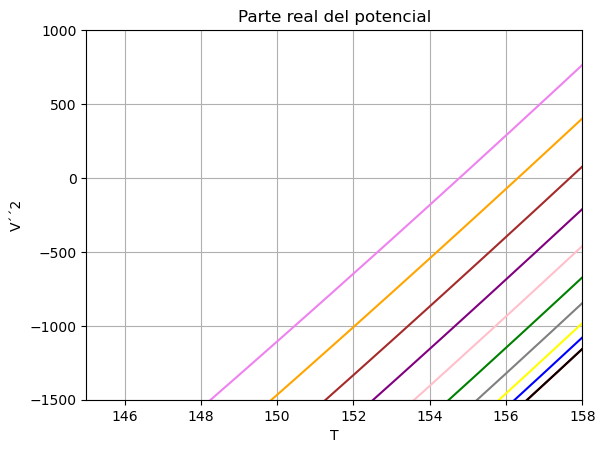

In [22]:
plt.figure(dpi = 100)
plt.plot(T_v, np.real(D2V[0,:]),  color='red')#, label='Mu_q = 0 Mev')
plt.plot(T_v, np.real(D2V[0]),  color='black')#, label='Mu_q = 10 Mev')
plt.plot(T_v, np.real(D2V[2]),  color='blue')#, label='Mu_q = 20 Mev')
plt.plot(T_v, np.real(D2V[3]),  color='yellow')#, label='Mu_q = 30 Mev')
plt.plot(T_v, np.real(D2V[4]),  color='grey')#, label='Mu_q = 40 Mev')
plt.plot(T_v, np.real(D2V[5]),  color='green')#, label='Mu_q = 50 Mev')
plt.plot(T_v, np.real(D2V[6]),  color='pink')#, label='Mu_q = 60 Mev')
plt.plot(T_v, np.real(D2V[7]),  color='purple')#, label='Mu_q = 70 Mev')
plt.plot(T_v, np.real(D2V[8]),  color='brown')#, label='Mu_q = 80 Mev')
plt.plot(T_v, np.real(D2V[9]),  color='orange')#, label='Mu_q = 90 Mev')
plt.plot(T_v, np.real(D2V[10]),  color='violet')#, label='Mu_q = 100 Mev')
plt.title('Parte real del potencial')
plt.xlim(145,158)
plt.ylim(-1500,1000)
plt.xlabel('T')
plt.ylabel('V´´2')
plt.grid(True)
#plt.legend()
plt.show()

In [23]:
#Enecuentra la raiz
def find_root(mu_q, T_v, lamda, m, g):
    def f(T):
        return np.real(Segunda_derivada(np.array([T]), mu_q, lamda, m, g))
    try:
        sol = root_scalar(f, bracket=[T_v[0], T_v[-1]], method='brentq')
        return sol.root if sol.converged else np.nan
    except ValueError:  # Manejar casos donde no hay cambio de signo
        return np.nan
        
#Encuentra la raiz para distintos valores de mu_q
def raiz(T_v, lamda, m, g):
    mu_q_values = np.arange(0, 101, 10)
    respuesta = [find_root(mu_q, T_v, lamda, m, g) for mu_q in mu_q_values]
    respuesta = np.array(respuesta)
    if np.isnan(respuesta[0]) or respuesta[0] == 0:  # Evitar división por cero
        return np.full_like(respuesta, np.nan)
    return respuesta

In [24]:
#genera las listas para graficar
tc = raiz(T_v, lamda, m, g)
print(tc)

mu_bar_v = []
for i in range(11):
    mu_bar_v.append((3*10*i))
mu_bar_v = np.array(mu_bar_v)

x = np.linspace(0,300,300)
y= 1 -0.0125287*x**2 - 0.0000765488*x**4

[162.75689638 162.67815203 162.44179337 162.04744344 161.49447365
 160.78200345 159.90890002 158.87377824 157.67500122 156.31068173
 154.77868514]


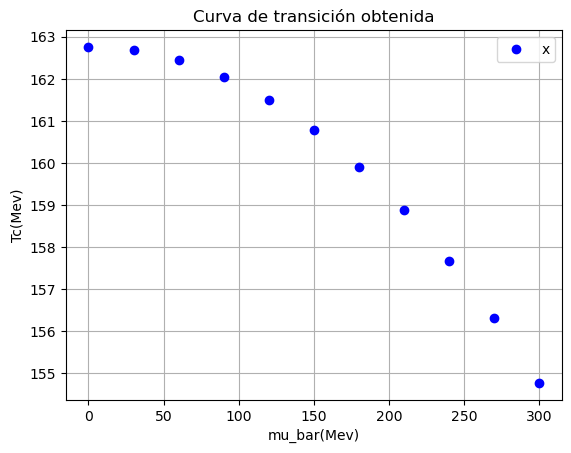

In [25]:
#Resultado de nuestra funcion raiz
plt.figure(dpi = 100)
plt.plot(mu_bar_v, tc, 'o' ,color='blue', label='x')
#plt.plot( x, y ,color='red')#, label='Mu_q = 0 Mev')
plt.title('Curva de transición obtenida')
#plt.xlim(0,2.1)
#plt.ylim(0.94,1.001)
plt.xlabel('mu_bar(Mev)')
plt.ylabel('Tc(Mev)')
plt.grid(True)
plt.legend()
plt.show()

In [26]:
#Discretiza la gráfica de LQCD
def Tf_QCD(mu_q):
  Tc = []
  for i in range(11):
    x = (10*3*i)
    Tc.append(158 - 0.000096*(x**2) + 8.1129e-11*(x**4))# valores multiplicados por TC_0
  Tc = np.array(Tc)
  return Tc

T_QCD_discreto = Tf_QCD(mu_q)
print(T_QCD_discreto)

mu_bar_qcd = []
for i in range(11):
    mu_bar_qcd.append(30*i)
mu_bar_qcd = np.array(mu_bar_qcd)

[158.         157.91366571 157.65545143 157.22772287 156.63442291
 155.88107156 154.97476598 153.92418049 152.73956655 151.43275277
 150.0171449 ]


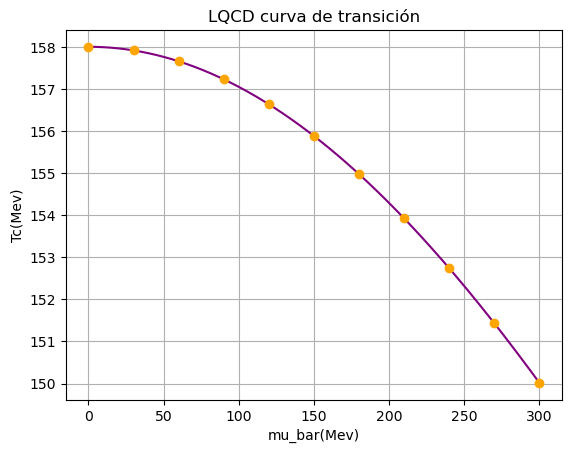

In [27]:
#Grafica la curva de transicion de LQCD discreta y continua
T_QCD = 158 - 0.000096*x**2 + 8.1129e-11*x**4
plt.figure(dpi = 100)
plt.plot( x, T_QCD ,color='purple', label='Tc/Tc_0 = 1 - 0.0153*(mu_b/Tc_0)*2 + 0.00032(mu_b/Tc_0)**4')
plt.plot( mu_bar_qcd, T_QCD_discreto , 'o',color='orange')#, label='Mu_q = 0 Mev')
plt.title('LQCD curva de transición')
#plt.xlim(0,2.1)
#plt.ylim(0.94,1.001)
plt.xlabel('mu_bar(Mev)')
plt.ylabel('Tc(Mev)')
plt.grid(True)
plt.show()

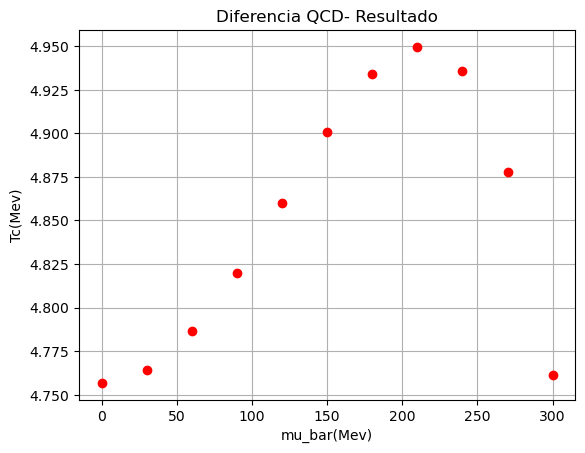

In [30]:
#Muestra la diferencia entre los resultados obtenidos y los de QCD
plt.figure(dpi = 100)
plt.plot( mu_bar_v , np.abs(T_QCD_discreto - tc) , 'o',color='red')#, label='Mu_q = 0 Mev')
plt.title('Diferencia QCD- Resultado')
#plt.xlim(0,2.1)
#plt.ylim(0.94,1.001)
plt.xlabel('mu_bar(Mev)')
plt.ylabel('Tc(Mev)')
plt.grid(True)
plt.show()

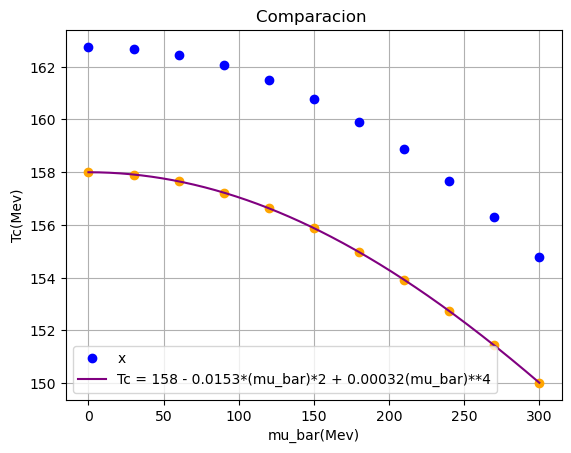

In [29]:
#Comparacion de los resultdaos obtenidos
plt.figure(dpi = 100)
plt.plot(mu_bar_v, tc, 'o' ,color='blue', label='x')
plt.plot( mu_bar_qcd, T_QCD_discreto , 'o',color='orange')#, label='Mu_q = 0 Mev')
plt.plot( x, T_QCD ,color='purple', label='Tc = 158 - 0.0153*(mu_bar)*2 + 0.00032(mu_bar)**4')
plt.title('Comparacion ')
#plt.xlim(0,2.1)
#plt.ylim(0.94,1.001)
plt.xlabel('mu_bar(Mev)')
plt.ylabel('Tc(Mev)')
plt.grid(True)
plt.legend()
plt.show()